## Setup

Set up the working environment:

In [ ]:
# To ensure reproducibility
seed = 99

# Load basic libraries
import os
import sys
from pathlib import Path

# Are we working on google colab?
if 'google.colab' in str(get_ipython()):
    
    from google.colab import drive
    drive.mount('/content/drive')
    
    # If so, look for the files on the drive location
    root_path = Path('content/drive/MyDrive/TFM')
    
else:
    
    # If the session is running local
    root_path = Path(os.path.abspath(".."))
    
    # Add path to Python's system
    if str(root_path) not in sys.path:
        sys.path.append(str(root_path))

# Create file paths
file_path = root_path / 'data' / 'clean' / 'HATCH_clinical_data.parquet'
results_path = root_path / 'results' / 'models'

Load libraries:

In [2]:
# DATA WRANGLING AND STATISTICS
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline

# HYPERPARAMETER TUNING
import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution, CategoricalDistribution
optuna.logging.set_verbosity(optuna.logging.WARNING)

# DATA PREPROCESSING
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from src.models.preprocessing import (get_regres_preprocessor, 
                                    get_geom_preprocessor, 
                                    get_bagg_preprocessor, 
                                    get_boost_preprocessor)

# MODEL TRAINING 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from src.models.training_and_evaluation import optimize_model_optuna_search, optimize_model_random_search

# CLINICAL SCORES
from src.models.risk_scores import compute_hatch_score, hatch_model_prediction

# MODEL EVALUATION
from src.models.plots import (plot_cm, 
                            plot_overfitting_bars, 
                            plot_combined_roc_curves,
                            plot_combined_pr_curves, 
                            plot_all_metrics_comparison)
from src.models.results import (save_model, 
                                save_scores, 
                                save_roc_curves_long_format,
                                save_pr_curves_long_format)



## Data

Load the data and check the structure: and split the data into target class and features:

In [3]:
# Load data
df = pd.read_parquet(file_path)

# Check general structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AF_recurrence  720 non-null    category
 1   age            720 non-null    float64 
 2   heart_failure  720 non-null    category
 3   hypertension   720 non-null    category
 4   COPD           720 non-null    category
 5   stroke         720 non-null    category
 6   OSA            720 non-null    category
dtypes: category(6), float64(1)
memory usage: 10.7 KB


Separate the features from the target class:

In [5]:
# Drop the target class and the non-informative features
X = df.drop(["AF_recurrence"], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train and test set:

In [6]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
    stratify=y,
    )

# Compute the predicted class ratio
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()

ratio = negatives / positives

print(f"Negative cases: {negatives}, Positive cases: {positives}")
print(f"Imbalance ratio suggested: {ratio:.2f}")

Negative cases: 367, Positive cases: 209
Imbalance ratio suggested: 1.76


## Training and optimization

Training each model with stratified 5-fold cross validation:

In [7]:
my_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

Define metrics to evaluate:

In [8]:
metrics = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'ROC-AUC', 'PR-AUC']

#### Logistic Regression (Elastic Net)

Define the parameter distributions and set up the pipeline:

In [9]:
# Hyperparameters search space
params_EN = {
    'clf__l1_ratio': FloatDistribution(0, 1),
    'clf__C': FloatDistribution(1e-4, 1e3, log=True)
    }

# Get the preprocessor
preprocessor_EN = get_regres_preprocessor(X_train)

# Full pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed,
                            solver='saga',
                            max_iter=10000))
])

Train and optimize the model:

In [10]:
(optimized_EN, 
train_metrics_mean_EN,
train_metrics_std_EN, 
val_metrics_mean_EN, 
val_metrics_std_EN, 
test_metrics_EN,
tpr_EN, fpr_EN,
precs_EN, recs_EN) = optimize_model_optuna_search(pipe_EN, params_EN, 
                                                X_train, y_train, X_test, y_test, 
                                                cv=my_cv, 
                                                seed=seed)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:78: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...


c:\Users\Miguel\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Miguel\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Miguel\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Miguel\min

Evaluating on the test set...


Training and evaluation completed!


c:\Users\Miguel\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Extract hyerparameters and display them to check if the distribution is wide enough:

In [11]:
best_params_EN = save_model(optimized_EN, results_path)

best_params_EN

,Hyperparameter,Optimal Value
1,C,0.021777
2,class_weight,None
3,dual,False
4,fit_intercept,True
5,intercept_scaling,1
6,l1_ratio,0.106976
7,max_iter,10000
8,n_jobs,None
9,penalty,deprecated
10,random_state,99


Check the confusion matrix:

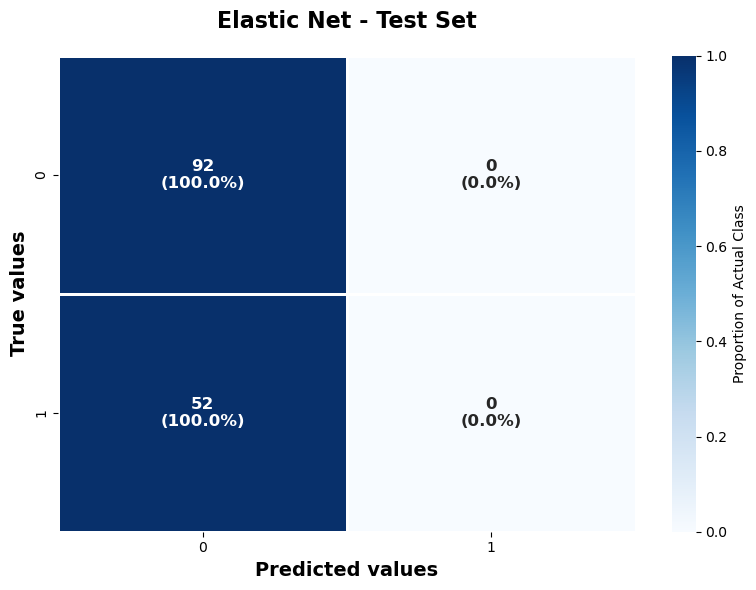

In [12]:
# Compute predictions for the test set
y_pred_EN = optimized_EN.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_EN, 
        title="Elastic Net - Test Set")

Check the overfitting:

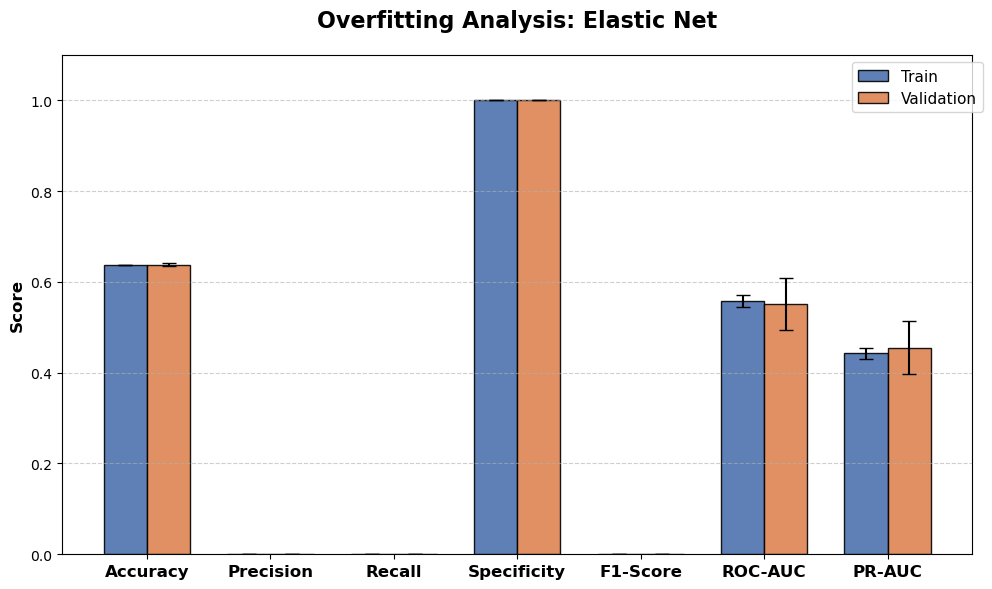

In [13]:
plot_overfitting_bars(train_metrics_mean_EN, val_metrics_mean_EN, 
                    train_metrics_std_EN, val_metrics_std_EN, 
                    model_name="Elastic Net")

### Support Vector Machine


Set up the pipeline and the parameter distributions:

In [14]:
# Hyperparameters search space
params_dist_SVM = {
    'clf__C': FloatDistribution(1e-4, 1e3, log=True),
    'clf__kernel': CategoricalDistribution(['linear', 'rbf', 'poly', 'sigmoid']),
    'clf__gamma': CategoricalDistribution(['scale', 'auto']), 
    'clf__degree': IntDistribution(2, 5),
    'clf__class_weight': CategoricalDistribution([None, 'balanced'])
}

# Get preprocessor
preprocessor_SVM = get_geom_preprocessor(X_train)

# Full pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed))
])

Train and optimize the model:

In [15]:
(optimized_SVM, 
train_metrics_mean_SVM,
train_metrics_std_SVM, 
val_metrics_mean_SVM, 
val_metrics_std_SVM, 
test_metrics_SVM,
tpr_SVM, fpr_SVM,
precs_SVM, recs_SVM) = optimize_model_optuna_search(pipe_SVM, params_dist_SVM, 
                                    X_train, y_train, X_test, y_test, 
                                    cv=my_cv)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:78: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [16]:
best_params_SVM = save_model(optimized_SVM, results_path)

best_params_SVM

,Hyperparameter,Optimal Value
1,C,0.092465
2,break_ties,False
3,cache_size,200
4,class_weight,balanced
5,coef0,0.0
6,decision_function_shape,ovr
7,degree,2
8,gamma,auto
9,kernel,sigmoid
10,max_iter,-1


Check the confusion matrix:

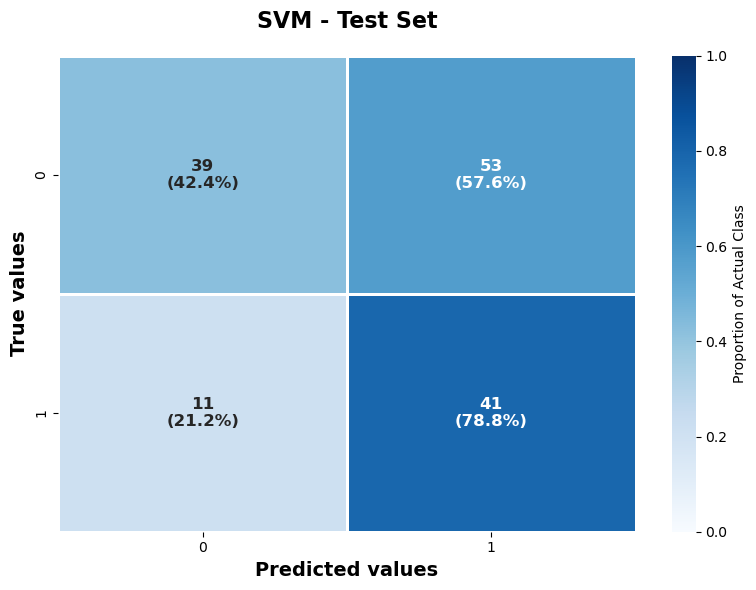

In [17]:
# Compute predictions for the test set
y_pred_SVM = optimized_SVM.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_SVM, 
        title="SVM - Test Set")

Check the overfitting:

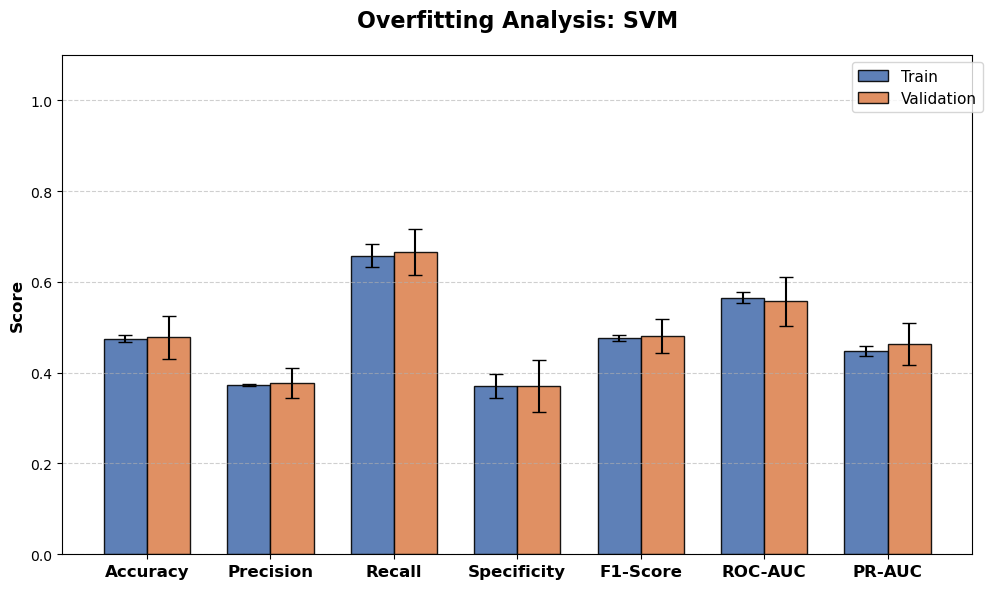

In [18]:
plot_overfitting_bars(train_metrics_mean_SVM, val_metrics_mean_SVM, 
                    train_metrics_std_SVM, val_metrics_std_SVM, 
                    model_name="SVM")

### Random Forest

Set up the pipeline and the parameters distributions:

In [19]:
# Hyperparameters search space
params_dist_RF = {
    'clf__n_estimators': IntDistribution(50, 300),
    'clf__max_depth': IntDistribution(2, 32),
    'clf__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'clf__min_samples_split': IntDistribution(2, 20),
    'clf__criterion': CategoricalDistribution(['gini', 'entropy']),
    'clf__class_weight': CategoricalDistribution([None, 'balanced', 'balanced_subsample'])
}

# Get the preprocessor
preprocessor_RF = get_bagg_preprocessor(X_train)

# Full pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

Train and optimize the model:

In [20]:
(optimized_RF, 
train_metrics_mean_RF,
train_metrics_std_RF, 
val_metrics_mean_RF, 
val_metrics_std_RF, 
test_metrics_RF,
tpr_RF, fpr_RF,
precs_RF, recs_RF) = optimize_model_optuna_search(pipe_RF, params_dist_RF, 
                                                X_train, y_train, X_test, y_test, 
                                                cv=my_cv)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:78: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [21]:
best_params_RF = save_model(optimized_RF, results_path)

best_params_RF

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,class_weight,balanced
4,criterion,gini
5,max_depth,3
6,max_features,log2
7,max_leaf_nodes,None
8,max_samples,None
9,min_impurity_decrease,0.0
10,min_samples_leaf,1


Check the confusion matrix:

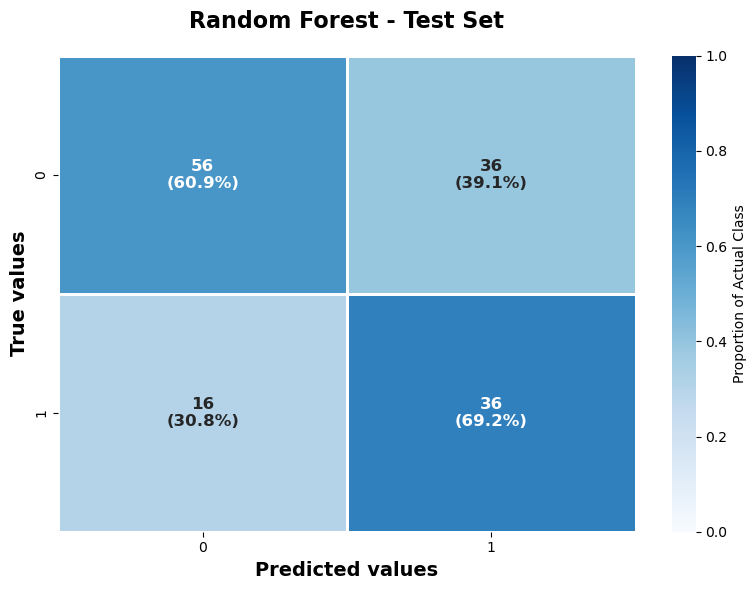

In [22]:
# Compute predictions for the test set
y_pred_RF = optimized_RF.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_RF, 
        title="Random Forest - Test Set")

Check the overfitting:

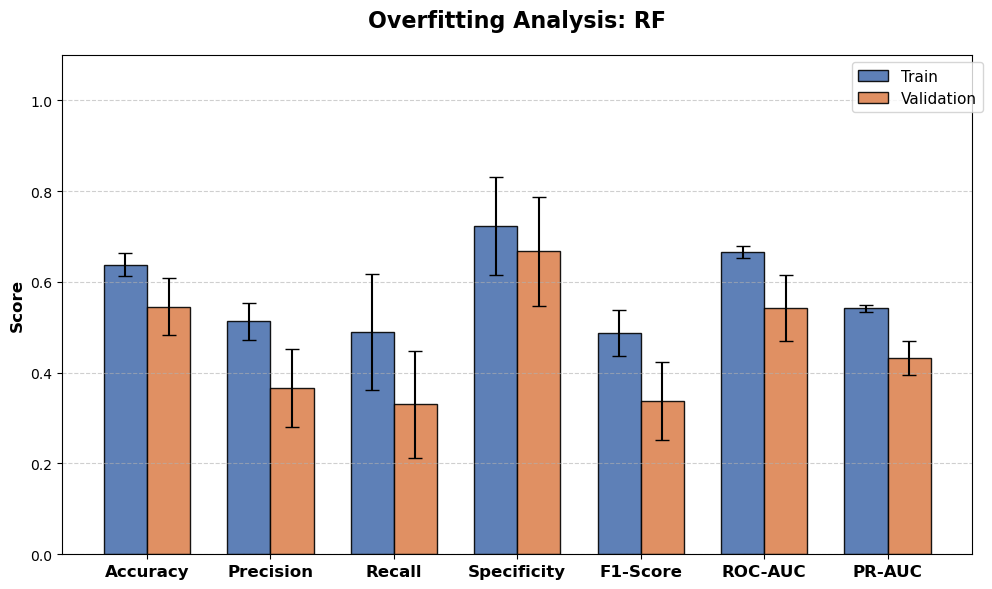

In [23]:
plot_overfitting_bars(train_metrics_mean_RF, val_metrics_mean_RF, 
                    train_metrics_std_RF, val_metrics_std_RF, 
                    model_name="RF")

### Extreme Gradient Boosting

Set up the pipeline and the parameters distributions:

In [24]:
# Hyperparameters search space
params_dist_XGB = {
    'clf__n_estimators': IntDistribution(20, 400),
    'clf__max_depth': IntDistribution(3, 10),
    'clf__learning_rate': FloatDistribution(0.01, 0.3),
    
    'clf__subsample': FloatDistribution(0.4, 0.6),
    'clf__colsample_bytree': FloatDistribution(0.4, 0.6),
    
    # Regularization parameters:
    'clf__reg_alpha': FloatDistribution(0, 10),
    'clf__reg_lambda': FloatDistribution(1, 10)
}

# Get the preprocessor
preprocessor_XGB = get_boost_preprocessor(X_train)

# Full pipeline
pipe_XGB = Pipeline(steps=[
    ('preprocessor', preprocessor_XGB),
    ('clf', XGBClassifier(random_state=seed,
                        scale_pos_weight=ratio, 
                        eval_metric='logloss'))
])

Train and optimize the model:

In [25]:
(optimized_XGB, 
train_metrics_mean_XGB,
train_metrics_std_XGB, 
val_metrics_mean_XGB, 
val_metrics_std_XGB, 
test_metrics_XGB,
tpr_XGB, fpr_XGB,
precs_XGB, recs_XGB) = optimize_model_optuna_search(pipe_XGB, params_dist_XGB,
                                                X_train, y_train, X_test, y_test, 
                                                cv=my_cv,
                                                seed=seed)

Starting hyperparameter optimization...


c:\Users\Miguel\Desarrollo\TFM\src\models\training_and_evaluation.py:78: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Training and evaluation completed!


Show hyperparameters to check if the distributions are wide enough:

In [26]:
best_params_XGB = save_model(optimized_XGB, results_path)

best_params_XGB

,Hyperparameter,Optimal Value
1,objective,binary:logistic
2,base_score,None
3,booster,None
4,callbacks,None
5,colsample_bylevel,None
6,colsample_bynode,None
7,colsample_bytree,0.463077
8,device,None
9,early_stopping_rounds,None
10,enable_categorical,False


Check the confusion matrix:

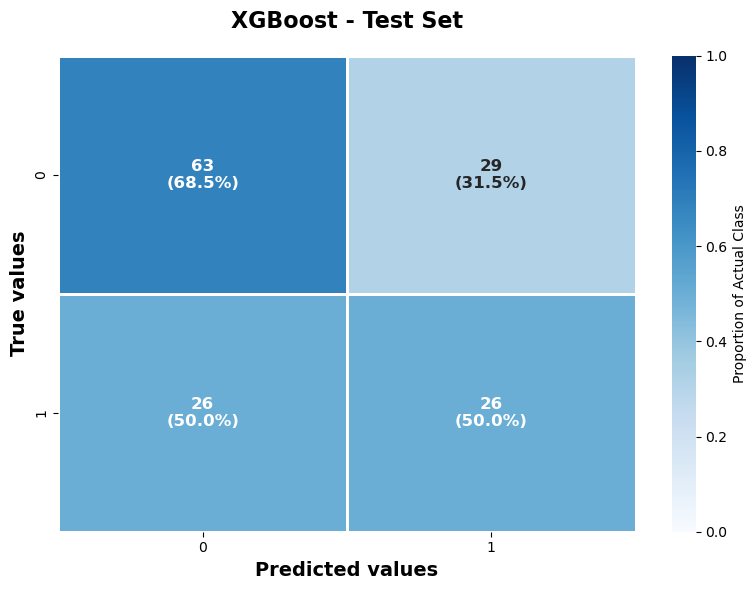

In [27]:
# Compute predictions for the test set
y_pred_XGB = optimized_XGB.predict(X_test)

# Display confusion matrix
plot_cm(y_true=y_test, y_pred=y_pred_XGB, 
        title="XGBoost - Test Set")

Check the overfitting:

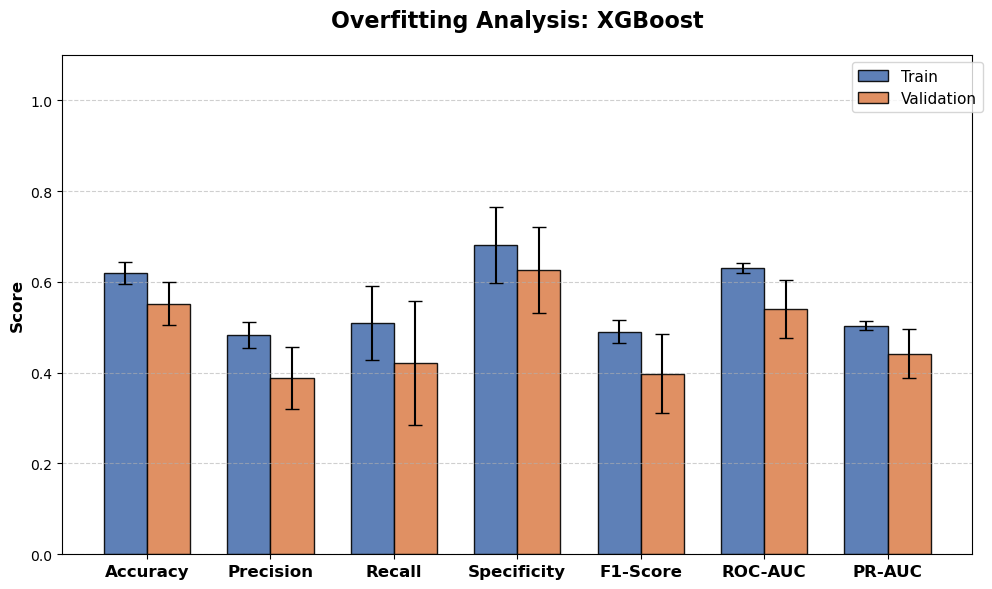

In [28]:
plot_overfitting_bars(train_metrics_mean_XGB, val_metrics_mean_XGB, 
                    train_metrics_std_XGB, val_metrics_std_XGB, 
                    model_name="XGBoost")

## Clinical models

### HATCH score

Load the data:

In [29]:
# # Set the file path
# hatch_file_path = root_path / 'data' / 'clean' / 'HATCH_clinical_data.parquet'

# # Load the dataset
# hatch_data = pd.read_parquet(hatch_file_path)

# hatch_data.head()

Train/test split:

In [30]:
# X_hatch = hatch_data.drop(["code", "AF_recurrence"], axis=1)
# y_hatch = hatch_data["AF_recurrence"].map({"no":0, "yes":1})

Compute the hatch score for each patient and make the predictions:

In [31]:
# # Compute the HATCH score for each patient and add it as a new column
# hatch_data['HATCH_score'] = compute_hatch_score(hatch_data)

## Comparison between models

### Individual scores

Join the basic metrics into a data frame where each column is a different metric and each row a different model. Mean scores:

In [32]:
# Get the model's names into a list
models = ['Elastic Net', 
        'SVM', 
        'Random Forest', 
        'XGBoost']

# Save the mean metrics of different models into a csv
train_metrics_mean=[train_metrics_mean_EN, train_metrics_mean_SVM, 
                train_metrics_mean_RF, train_metrics_mean_XGB]
validation_metrics_mean=[val_metrics_mean_EN, val_metrics_mean_SVM, 
                        val_metrics_mean_RF, val_metrics_mean_XGB]
test_metrics_mean=[test_metrics_EN, test_metrics_SVM, test_metrics_RF, test_metrics_XGB]

(test_results, 
mean_train_results, 
mean_val_results) = save_scores(models, test_metrics=test_metrics_mean, 
                        train_metrics=train_metrics_mean,
                        validation_metrics=validation_metrics_mean,
                        results_path=results_path,
                        prefix="mean")


Standard deviations associated to each mean score:

In [33]:
# Save the metrics' std of different models into a csv
train_metrics_std=[train_metrics_std_EN, train_metrics_std_SVM, train_metrics_std_RF, train_metrics_std_XGB]
validation_metrics_std=[val_metrics_std_EN, val_metrics_std_SVM, val_metrics_std_RF, val_metrics_std_XGB]
test_metrics_std=[None for model in models]

(_, 
std_train_results, 
std_val_results) = save_scores(models, 
                        test_metrics=test_metrics_std,
                        train_metrics=train_metrics_std,
                        validation_metrics=validation_metrics_std,
                        results_path=results_path,
                        prefix="std")

Draw barplots to compare different models:

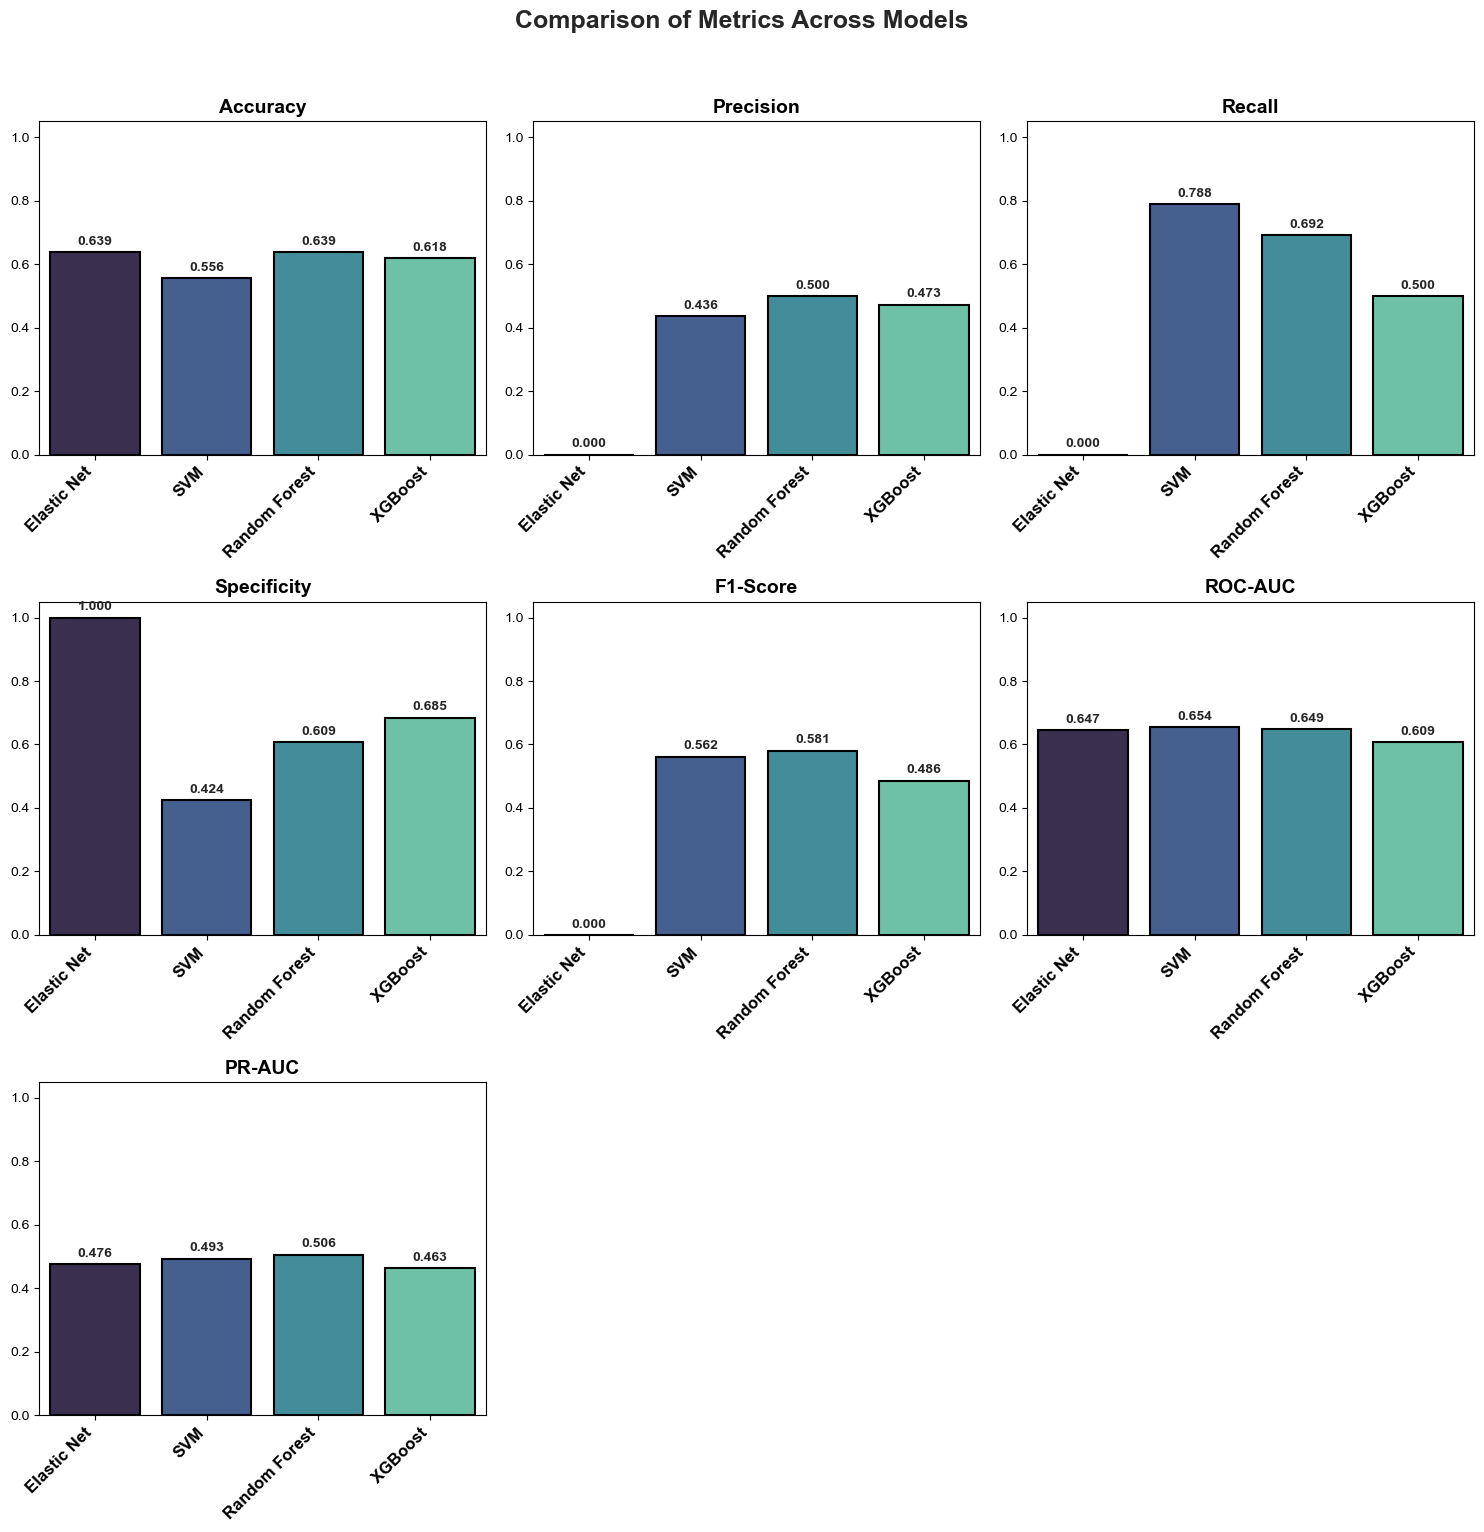

In [34]:
plot_all_metrics_comparison(test_results, metrics=metrics, color_palette='mako')

### Curves

#### ROC Curves

Join the metrics

In [35]:
# Save the false/true positive rates values into a csv
fpr = [fpr_EN, fpr_SVM, fpr_RF, fpr_XGB]
tpr = [tpr_EN, tpr_SVM, tpr_RF, tpr_XGB]

roc_results = save_roc_curves_long_format(models, tpr, fpr, 
                            results_path=results_path, prefix="roc_curves")

Plot combined curves:

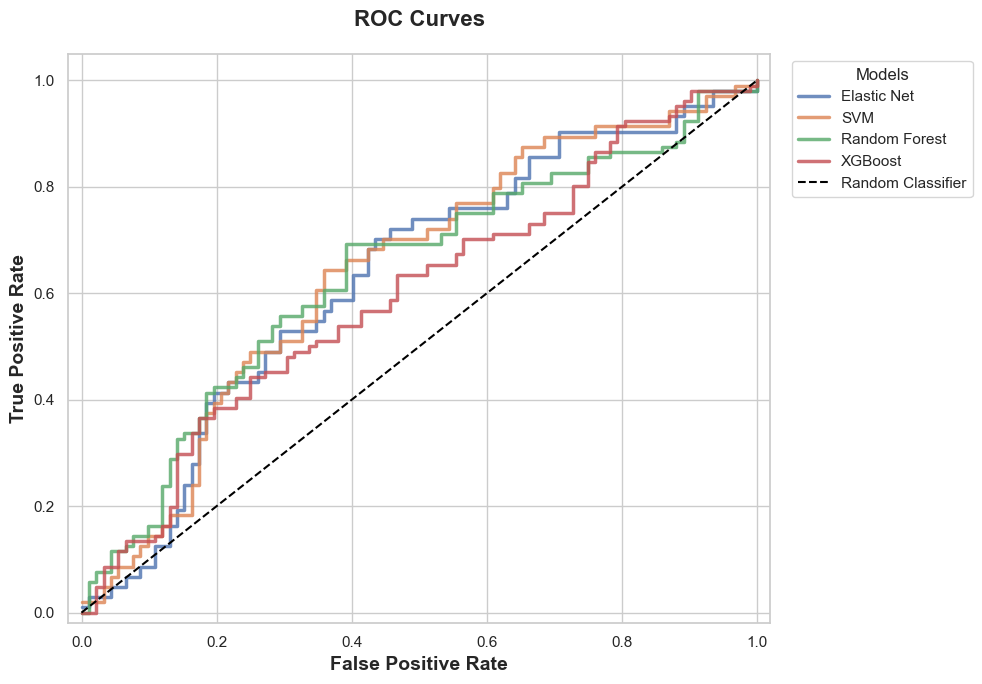

In [36]:
plot_combined_roc_curves(roc_results)

#### PR Curves

Join the curves metrics (precision and recall scores at different thresholds):

In [37]:
# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_RF, precs_XGB]
recs = [recs_EN, recs_SVM, recs_RF, recs_XGB]

pr_results = save_pr_curves_long_format(models, precs, recs, 
                                        results_path=results_path, 
                                        prefix="pr_curves")

Plot the precision-recall curves:

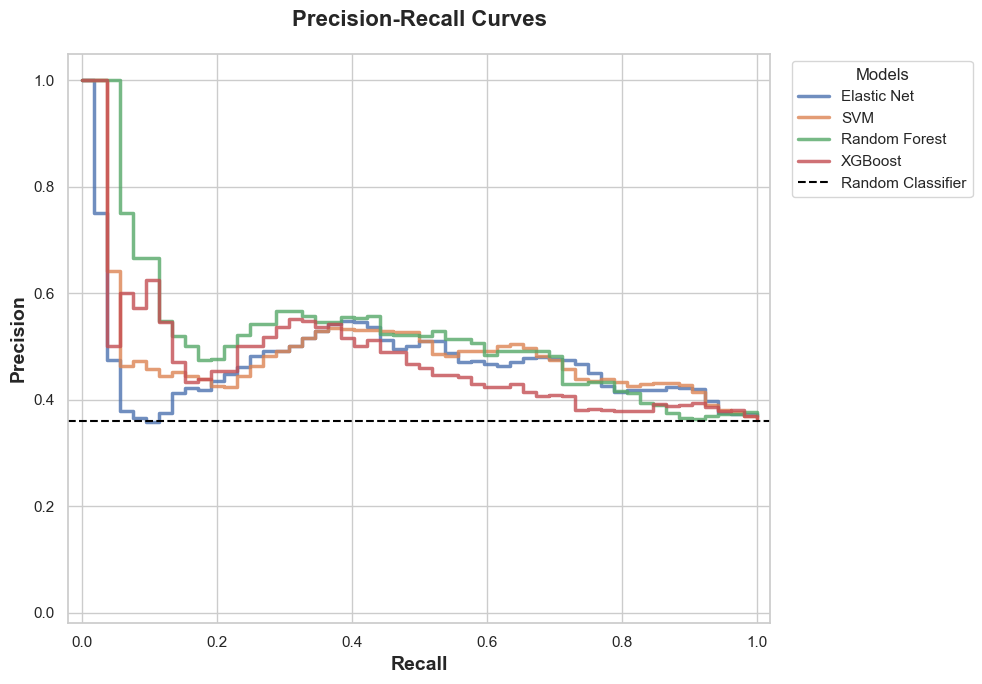

In [38]:
plot_combined_pr_curves(pr_results)